# Optimizer profile: Sven backends
Batch-size scaling, the chunk-size memory/time trade-off, and rank dependence.

In [1]:
import sys
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from style import set_style
import profile_helpers as ph
set_style()
PLOT_DIR = 'plots_v2/profile'
df = ph.load_profiles()          # ../profile_results_v2/*/*.json -> one tidy row per configuration
ARCHS = [a for a in ph.ARCH_ORDER if a in set(df.arch)]
df.groupby(['arch', 'study']).size().unstack(fill_value=0)

study,batch_size,chunk_fraction,k,methods,microbatch,param_fraction,width
arch,,,,,,,
cifar_resnet18,16,5,8,16,10,26,0
mnist,36,6,15,17,21,48,0
mnist_width,0,0,0,0,0,0,91
nanogpt,25,5,12,17,15,18,0
nanogpt_width,0,0,0,0,0,0,55
polynomial,36,4,15,17,18,39,0
toy_1d,36,4,15,17,18,39,0


### Batch size
The Gram matrix is $B^2$; the materialised Jacobian is $B\cdot P$ (dotted lines: the analytic $B P \cdot 4$ bytes). Red crosses are configurations that ran out of memory.

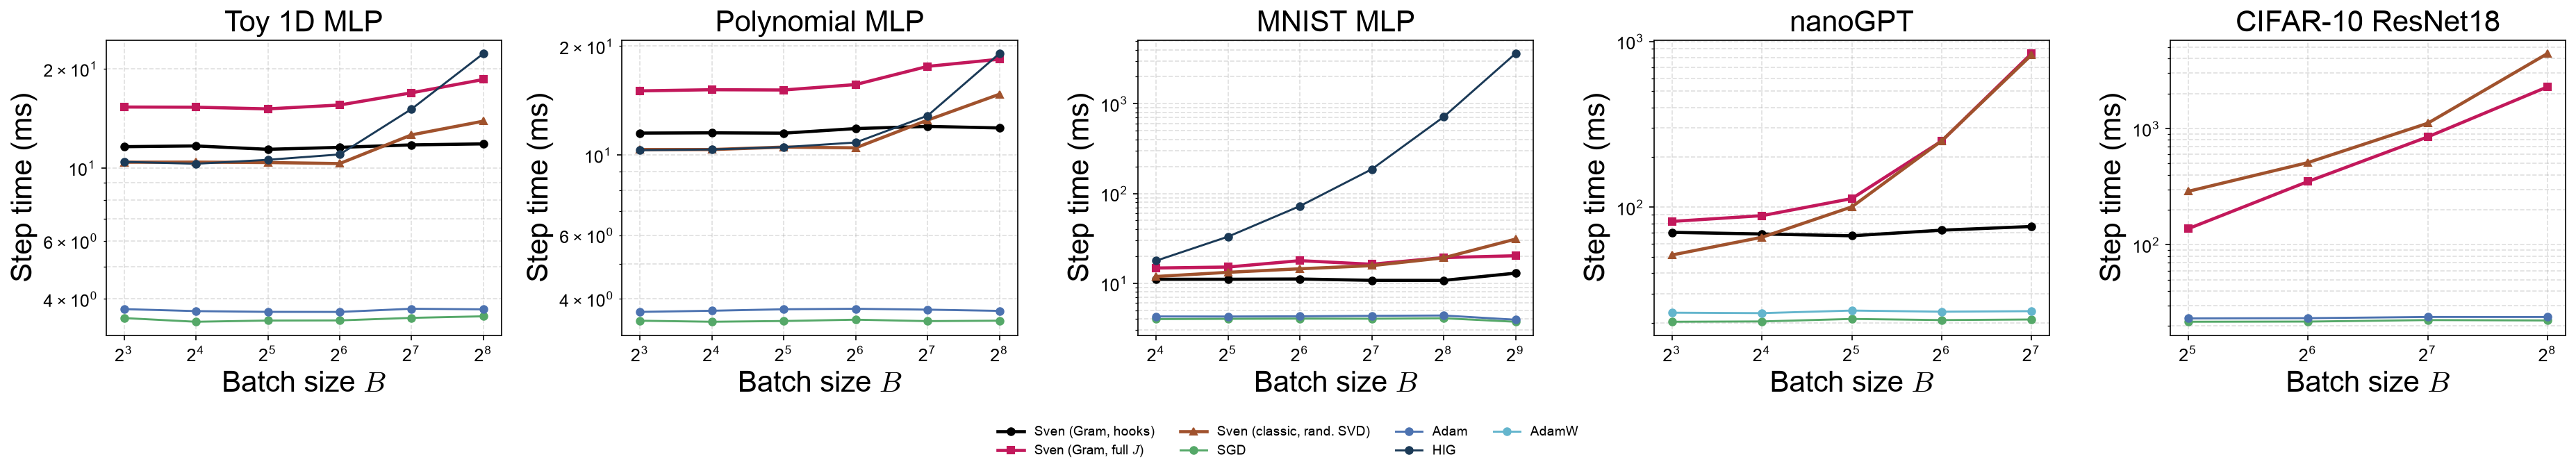

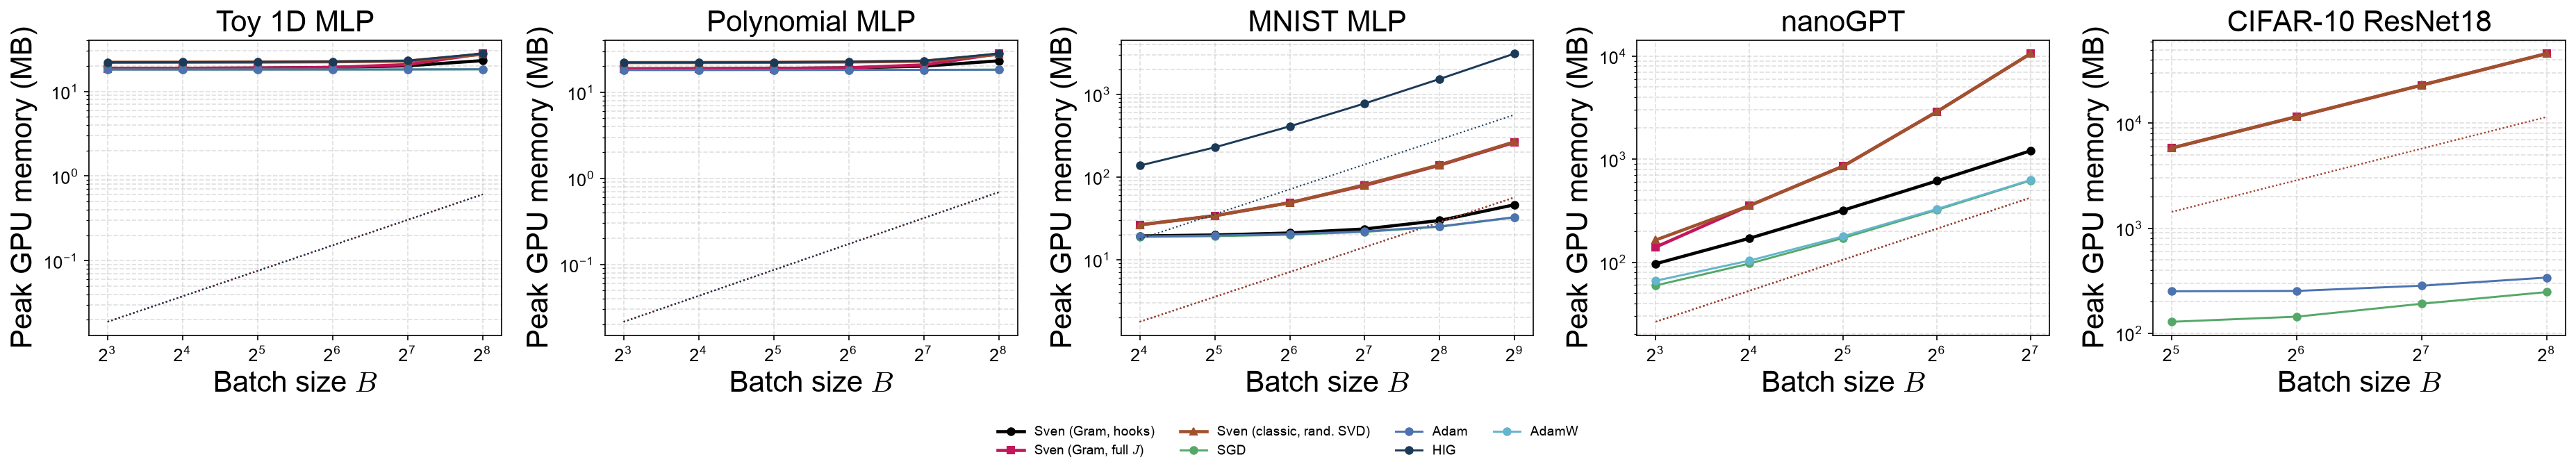

In [2]:
for value, analytic, fname in [('step_ms', None, 'batchsize_step_time'), ('peak_mb', 'analytic_jac_mb', 'batchsize_peak_memory')]:
    fig, axes = plt.subplots(1, len(ARCHS), figsize=(5 * len(ARCHS), 4.2), squeeze=False)
    for ax, arch in zip(axes[0], ARCHS):
        ph.plot_sweep(df, arch, 'batch_size', 'B', ax, value=value, analytic=analytic)
    ph.legend_below(fig, axes[0][0])
    fig.tight_layout(); ph.save(fig, f'{fname}.pdf', PLOT_DIR); plt.show()

### Chunk size
`gram_chunked` differentiates parameter groups of $f\cdot P$ elements, one `jacrev` each: smaller chunks cap the Jacobian block held in memory and cost more passes.

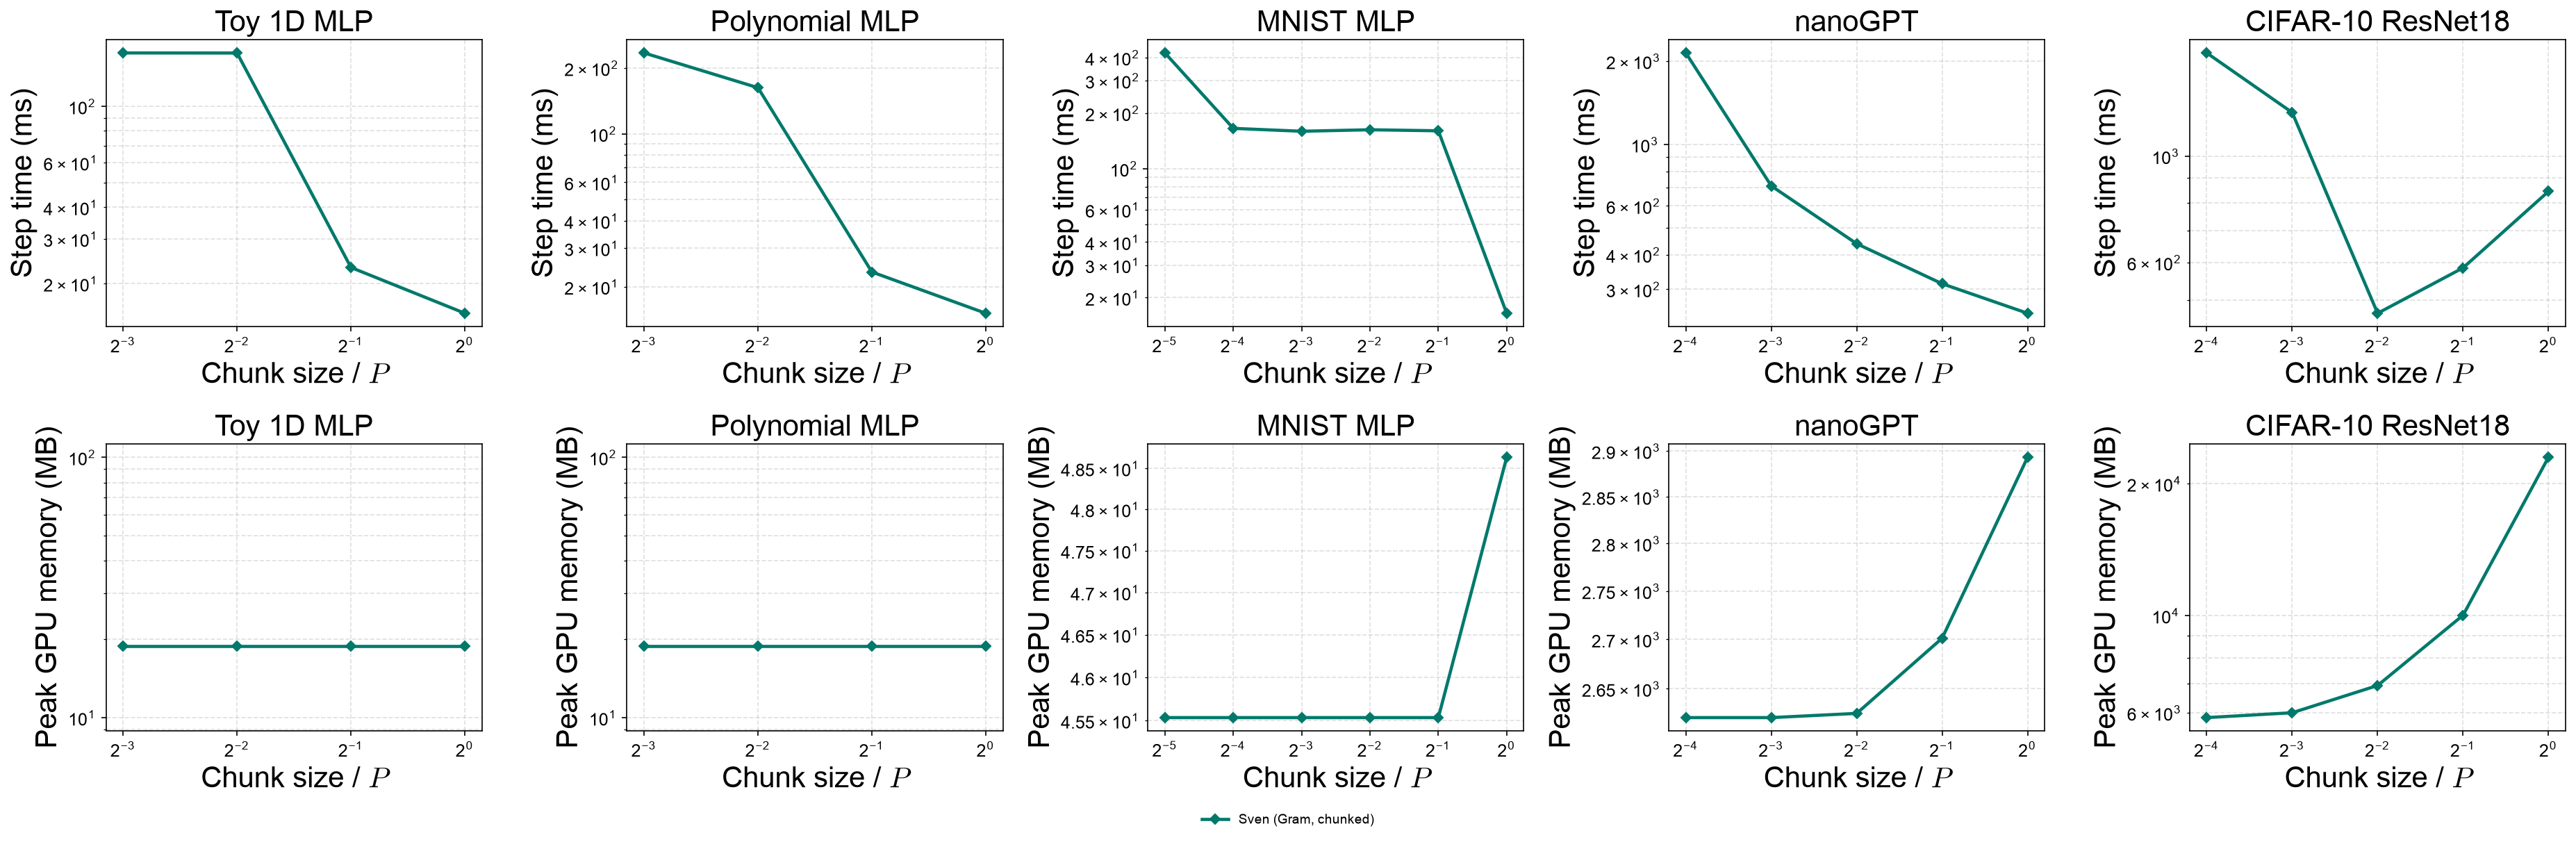

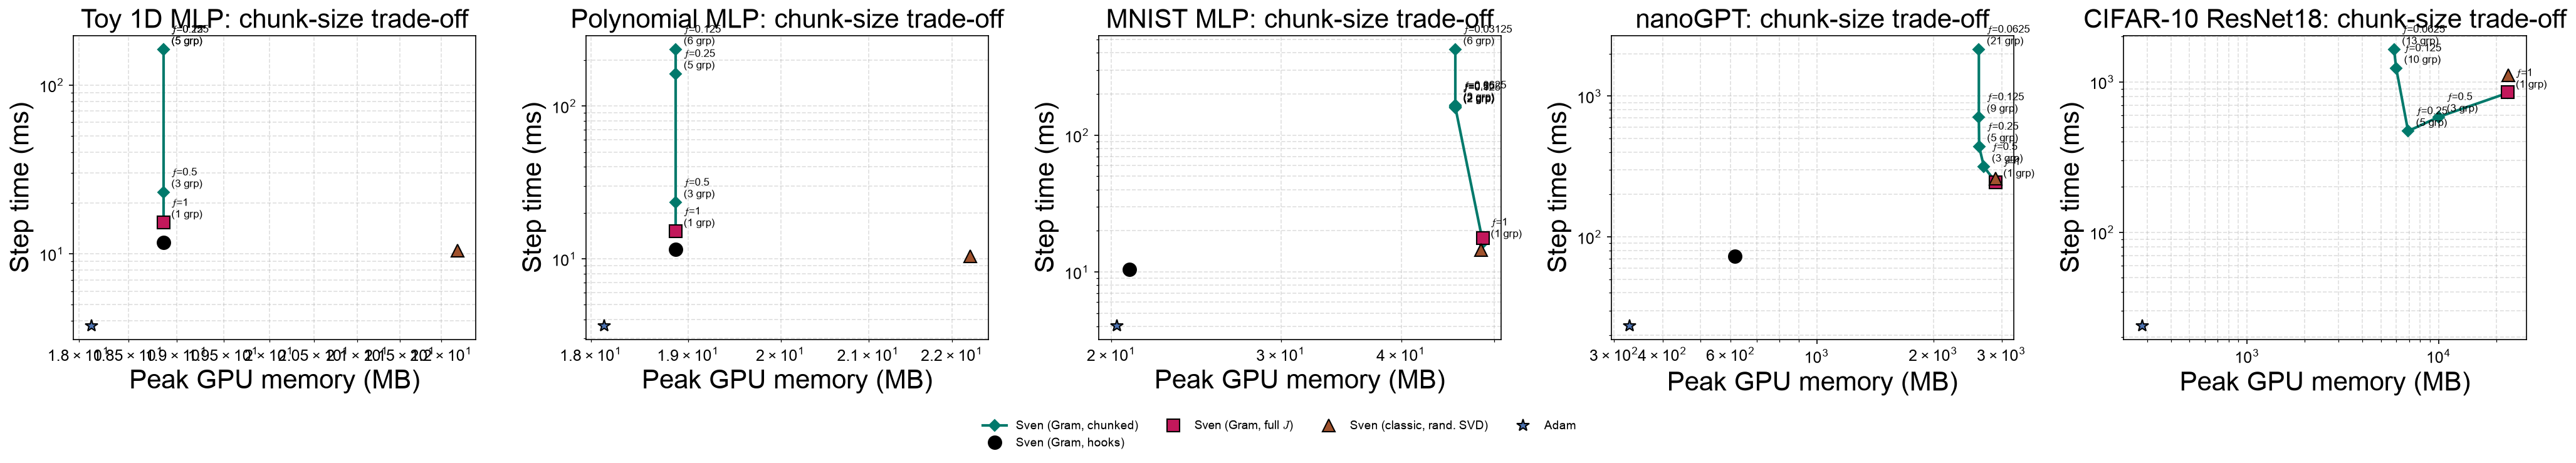

,arch,chunk_fraction,n_groups,step_ms,peak_mb,status
16,cifar_resnet18,0.06250,13.0,1640.871087,5847.690752,ok
17,cifar_resnet18,0.12500,10.0,1232.742429,5998.947840,ok
18,cifar_resnet18,0.25000,5.0,470.148228,6922.743296,ok
19,cifar_resnet18,0.50000,3.0,584.698518,10016.493056,ok
20,cifar_resnet18,1.00000,1.0,844.070312,22977.711104,ok
117,mnist,0.03125,6.0,423.681647,45.534208,ok
118,mnist,0.06250,3.0,165.305721,45.534208,ok
119,mnist,0.12500,2.0,159.458006,45.534208,ok
120,mnist,0.25000,2.0,162.493617,45.534208,ok
121,mnist,0.50000,2.0,160.367667,45.534208,ok


In [3]:
CH = [a for a in ARCHS if len(df[(df.arch == a) & (df.study == 'chunk_fraction')])]
fig, axes = plt.subplots(2, len(CH), figsize=(5 * len(CH), 8), squeeze=False)
for j, arch in enumerate(CH):
    ph.plot_sweep(df, arch, 'chunk_fraction', 'chunk_fraction', axes[0][j], value='step_ms')
    ph.plot_sweep(df, arch, 'chunk_fraction', 'chunk_fraction', axes[1][j], value='peak_mb')
ph.legend_below(fig)
fig.tight_layout(); ph.save(fig, 'chunk_fraction_sweeps.pdf', PLOT_DIR); plt.show()

fig, axes = plt.subplots(1, len(CH), figsize=(5.5 * len(CH), 4.6), squeeze=False)
for ax, arch in zip(axes[0], CH):
    ph.plot_pareto(df, arch, ax)
ph.legend_below(fig, axes[0][0])
fig.tight_layout(); ph.save(fig, 'chunk_fraction_pareto.pdf', PLOT_DIR); plt.show()
df[df.study == 'chunk_fraction'][['arch', 'chunk_fraction', 'n_groups', 'step_ms', 'peak_mb', 'status']].sort_values(['arch', 'chunk_fraction'])

### Rank $k$
The Gram solve is a $B\times B$ `eigh` whatever $k$ is; the randomized SVD of the classic path projects onto $k+5$ directions, so its cost moves with $k$.

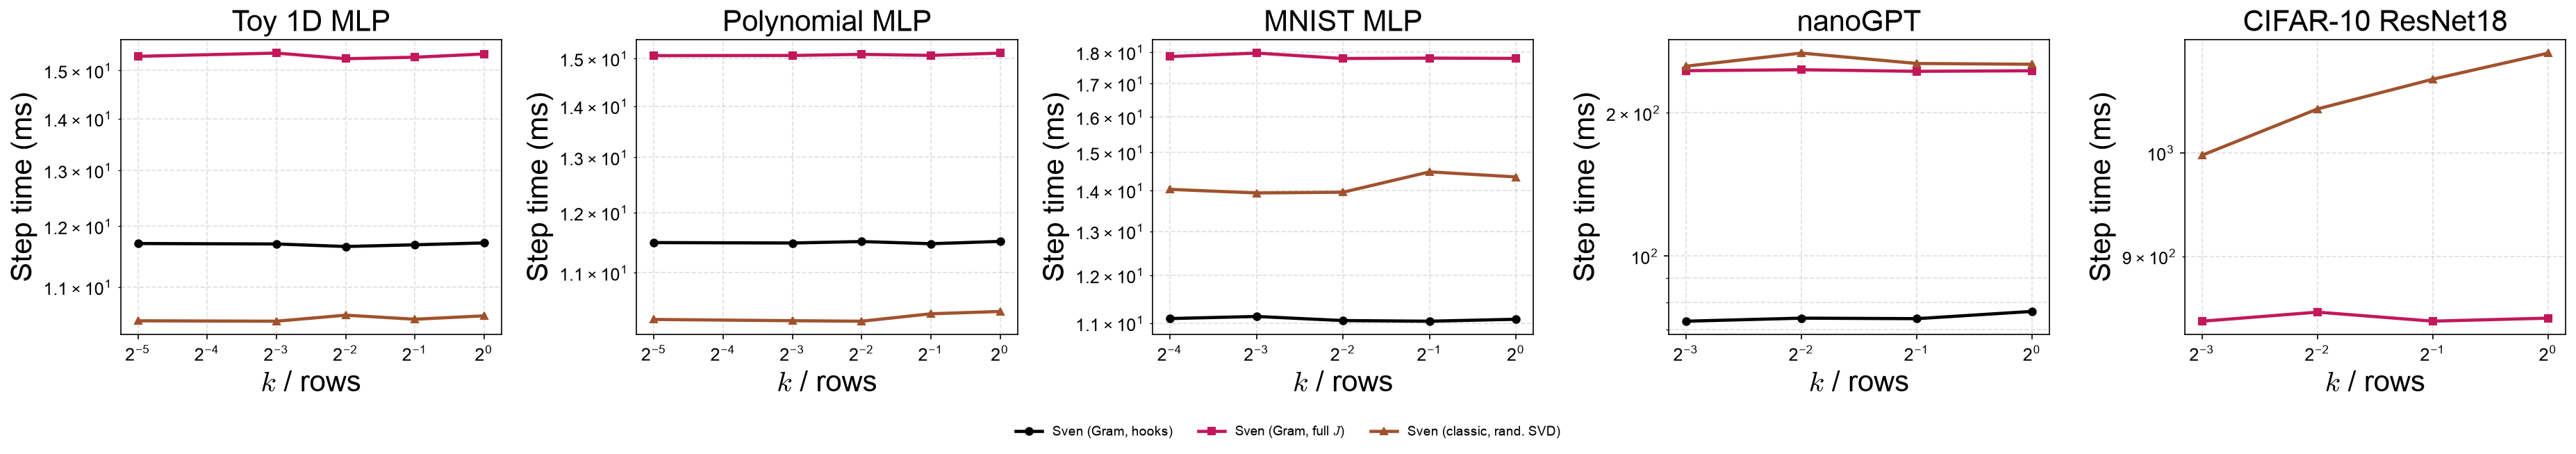

In [4]:
fig, axes = plt.subplots(1, len(ARCHS), figsize=(5 * len(ARCHS), 4.2), squeeze=False)
for ax, arch in zip(axes[0], ARCHS):
    ph.plot_sweep(df, arch, 'k', 'k_fraction', ax, value='step_ms')
ph.legend_below(fig, axes[0][0])
fig.tight_layout(); ph.save(fig, 'k_sweep_step_time.pdf', PLOT_DIR); plt.show()

### Capture vs solve, across batch size

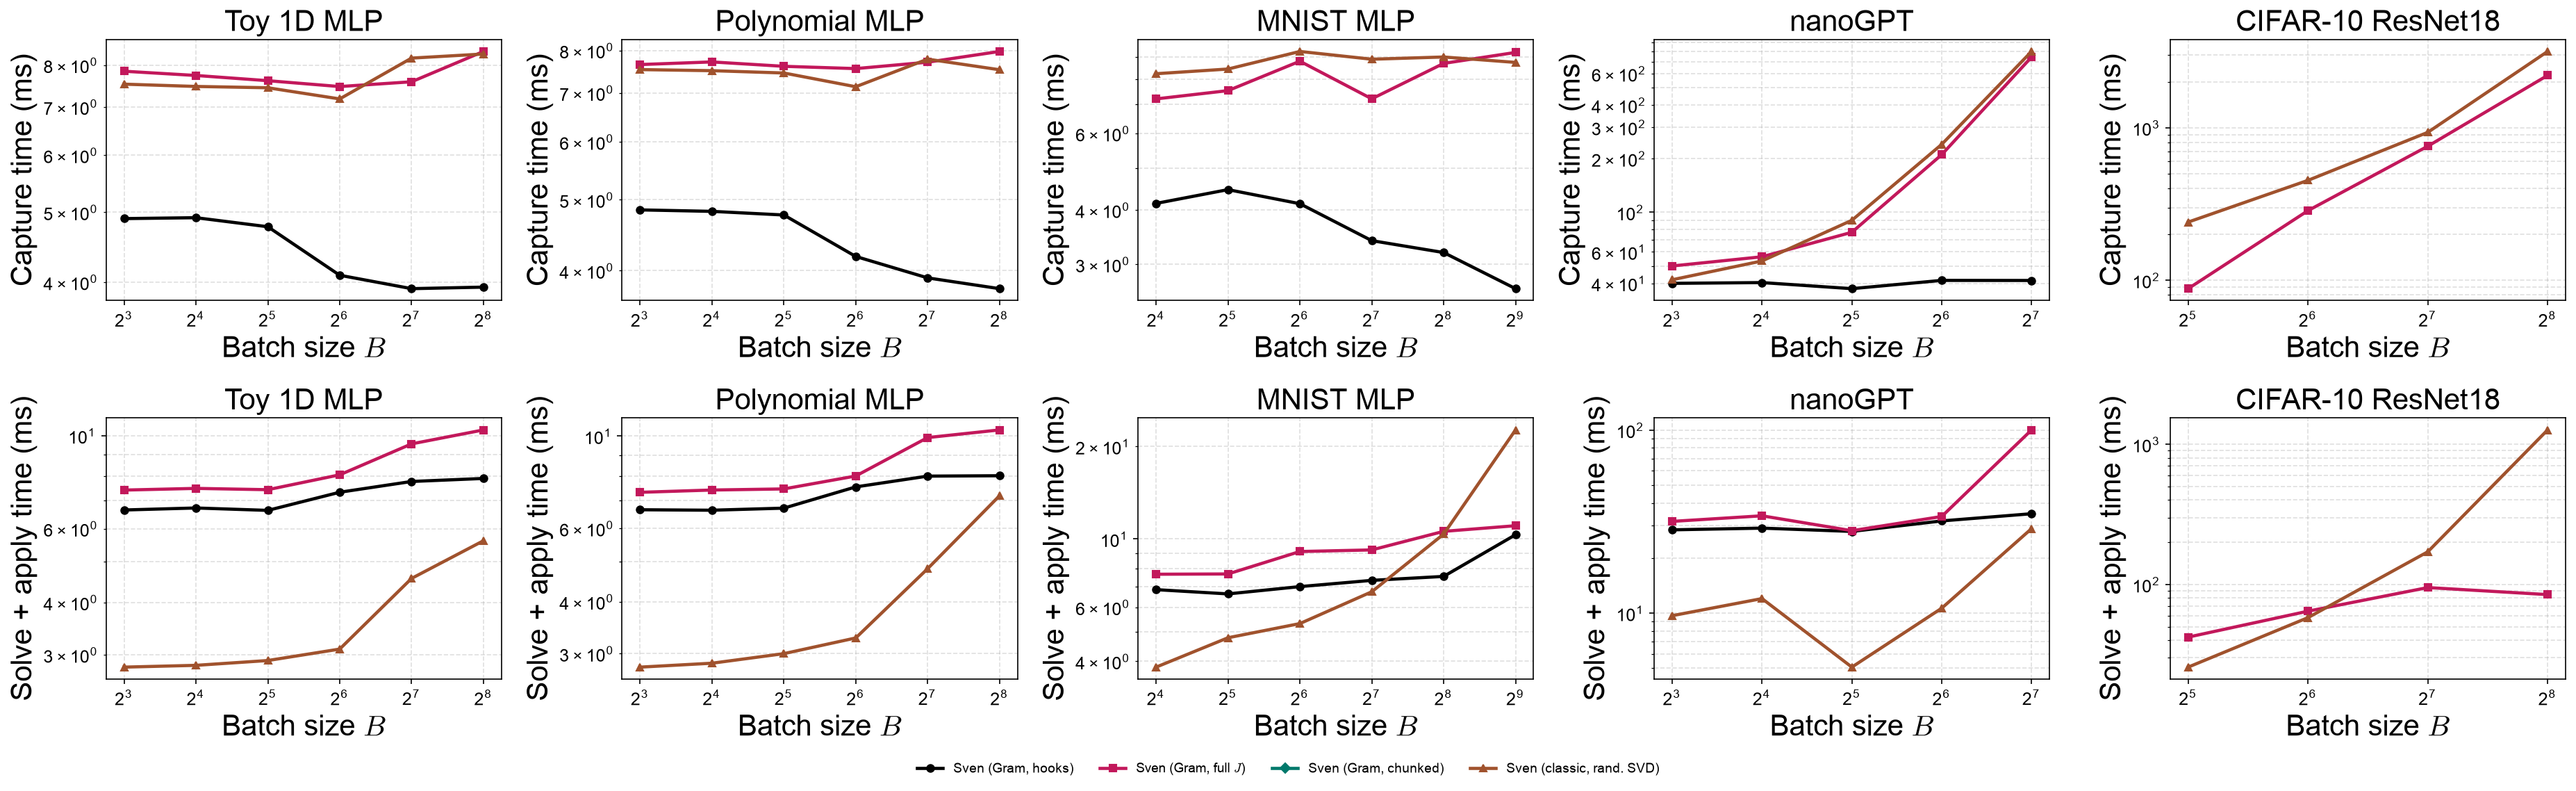

In [5]:
fig, axes = plt.subplots(2, len(ARCHS), figsize=(5 * len(ARCHS), 7.5), squeeze=False)
for j, arch in enumerate(ARCHS):
    ph.plot_sweep(df, arch, 'batch_size', 'B', axes[0][j], value='capture_ms', methods=ph.SVEN)
    ph.plot_sweep(df, arch, 'batch_size', 'B', axes[1][j], value='solve_ms', methods=ph.SVEN)
ph.legend_below(fig)
fig.tight_layout(); ph.save(fig, 'batchsize_capture_vs_solve.pdf', PLOT_DIR); plt.show()